In [45]:
# Code block 0.1

# Import some non-landlab libraries
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Import from the landlab library
from landlab import RasterModelGrid, imshow_grid, imshowhs_grid
from landlab.components import FastscapeEroder, FlowAccumulator, LinearDiffuser, ChannelProfiler
from landlab.plot.graph import plot_graph
from tqdm import trange

In [46]:
##HII

In [47]:
import numpy as np
from landlab import RasterModelGrid
import matplotlib.pyplot as plt
from landlab.components import (
    FlowAccumulator,
    DepressionFinderAndRouter,
    Space,
    FastscapeEroder,
)

### Instantiate a grid

In [48]:
num_rows = 150  # number of grid rows
num_cols = 200  # number of grid columns
dxy = 10  # resolution of raster cell [m], or node horizontal and vertical spacing

# Create the grid
mg = RasterModelGrid((num_rows, num_cols), dxy)

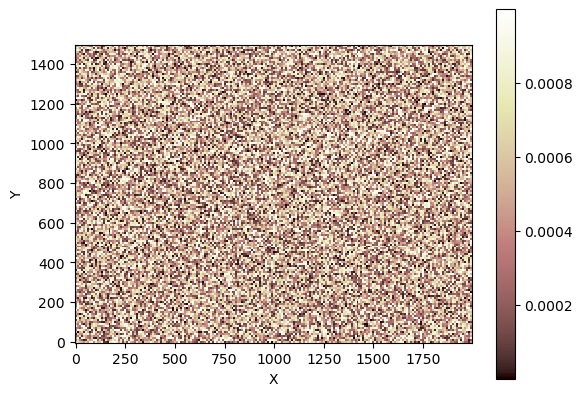

In [49]:
# Make some noise to add to the initial topography.
# This is not necessary, but it is a trick to make networks look more `real`

np.random.seed(0)  
mg_noise = np.random.rand(mg.number_of_nodes) / 1000.0  # intial noise on elevation grid

# Set-up the elevation field on the grid
zr = mg.add_zeros("topographic__elevation", at="node")
zr += mg_noise

# Plot the elevation map
imshow_grid(mg, "topographic__elevation")

### Set parameters and create an instance of the flow accumulation and fluvial erosion components

In [50]:
# Stream power parameters
K_sp = 1.0e-5  # erodibility, units depend on m and n exponents
m_sp = 0.5  # exponent on drainage area
n_sp = 1.0  # exponent on slope

# Create the flow accumulation and fluvial incision components
fr = FlowAccumulator(mg, flow_director="D8")
fs = FastscapeEroder(mg, m_sp=m_sp, n_sp=n_sp, K_sp=K_sp)

### Set model time and uplift parameters

In [51]:
dt = 1000  # time step [yr]
modeled_time = 0  # amount of time the landscape has evolved [yr]
time_to_run = 3e6  # time for the model loop to run [yr]

nsteps = int(time_to_run / dt)  # number of model time steps

uplift_rate = 0.0001  # uplift rate [m/yr]
uplift_length = uplift_rate * dt # length of uplift per time step [m]

In [52]:
# close every edge
mg.set_closed_boundaries_at_grid_edges(True, True, True, True)
outlet_node = 0
# reopen just that node as a fixed-value outlet
mg.status_at_node[outlet_node] = mg.BC_NODE_IS_FIXED_VALUE

### Run the fluvial model

In [53]:
for i in range(nsteps):
    zr[mg.core_nodes] += uplift_length  # uplift the landscape
    fr.run_one_step()  # route flow
    fs.run_one_step(dt)  # fluvial incision
    modeled_time += dt  # update time keeper
    
    # sometimes it's nice to see that the model is progressing, especially if it's slow
    if int(modeled_time % 1e5) == 0:
        print("model run time",modeled_time)
        print("maximum elevation",max(mg.at_node["topographic__elevation"][mg.core_nodes]))
        

model run time 100000
maximum elevation 10.000693887971533
model run time 200000
maximum elevation 20.000451005436364
model run time 300000
maximum elevation 30.000278291335178
model run time 400000
maximum elevation 40.00019491564104
model run time 500000
maximum elevation 50.00013180283757
model run time 600000
maximum elevation 60.00008971551122
model run time 700000
maximum elevation 70.00006420701115
model run time 800000
maximum elevation 80.0000522178176
model run time 900000
maximum elevation 90.00003751271377
model run time 1000000
maximum elevation 100.00002468209748
model run time 1100000
maximum elevation 110.0000174624747
model run time 1200000
maximum elevation 120.00001245227273
model run time 1300000
maximum elevation 130.00000875944897
model run time 1400000
maximum elevation 140.00000687870573
model run time 1500000
maximum elevation 150.00000514805544
model run time 1600000
maximum elevation 160.00000057556184
model run time 1700000
maximum elevation 169.977485338520

### Visualize the topography

In [55]:
# imshow_grid(mg, "topographic__elevation")
max(mg.at_node["topographic__elevation"])

np.float64(108.83034257322177)

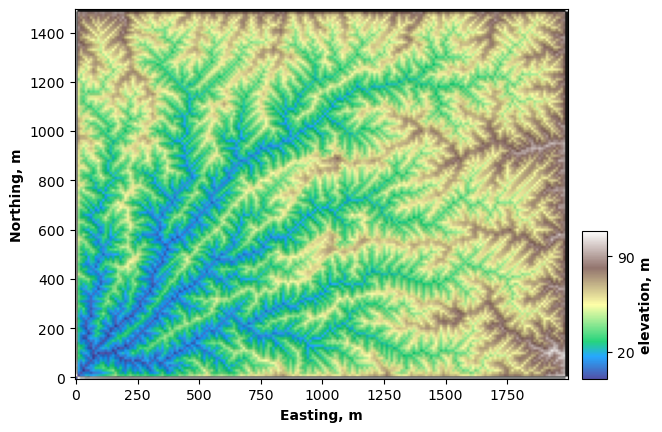

In [56]:
# Elevation map draped over shaded relief
# Don't get thrown off by all the parameter values.
# They are included because this function makes beautiful visualizations,
# and it can be helpful to `see` different aspects of the landscape by changing
# the parameters.

cmap = mpl.colormaps["terrain"]
plot_type = "Drape1"
#plot_type = "DEM"
drape1 = "topographic__elevation"
ax = imshowhs_grid(
    mg,
    "topographic__elevation",
    plot_type=plot_type,
    drape1=drape1,
    alpha=0.85,
#    altdeg=55.,
#    azdeg=180,
    cmap=cmap,
    grid_units=("m", "m"),
    default_fontsize=10,
    cbar_tick_size=10,
    var_name="elevation, m",
    cbar_width="100%",
    cbar_or="vertical",
    bbox_to_anchor=[1.03, 0.0, 0.05, 8],
    colorbar_label_y=3,
    #colorbar_label_x=-100,
    ticks_km=False,
)

### A drainage area map

Because drainage area varies by orders of magnitude, it is often easier to visualize on a log scale. Plotting drainage area is one way to visualize the networks. It is also helpful to see if the model has developed continuous networks.

Text(0.5, 1.0, 'log10 of drainage area, time = 3000000')

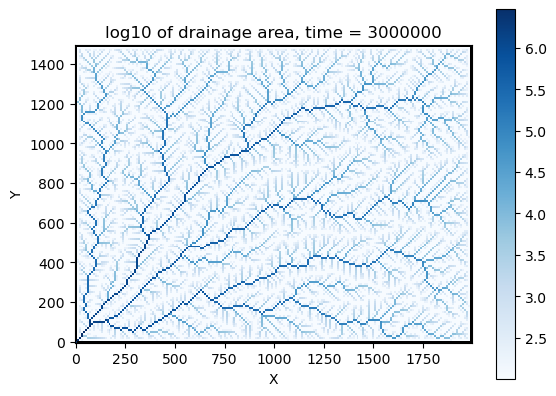

In [57]:
# calculate the log of drainage area array
log10area = np.log10(mg.at_node["drainage_area"] + 1.0)

# make the map
imshow_grid(mg, log10area, cmap="Blues")
title_text = f"log10 of drainage area, time = {modeled_time}"
mpl.pyplot.title(title_text)

## Space Tryout Tutorial

In [58]:
import numpy as np
from landlab import RasterModelGrid
from landlab.components import (
    FlowAccumulator,
    DepressionFinderAndRouter,
    Space,
    FastscapeEroder,
)

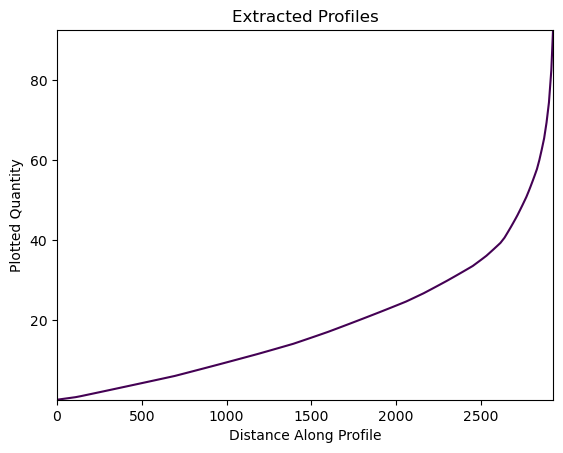

In [59]:
profiler = ChannelProfiler(
    mg,)
profiler.run_one_step()
profiler.plot_profiles()

In [60]:
# mg = RasterModelGrid((5, 5), xy_spacing=10.0)
# _ = mg.add_zeros("topographic__elevation", at="node")
# mg.at_node["topographic__elevation"] += (
#     mg.node_y / 10.0 + mg.node_x / 10.0 + np.random.rand(len(mg.node_y)) / 10.0)
# mg.set_closed_boundaries_at_grid_edges(bottom_is_closed=True,left_is_closed=True,right_is_closed=True,
# top_is_closed=True)
# mg.set_watershed_boundary_condition_outlet_id(
#     0, mg.at_node["topographic__elevation"], -9999.0)
# fsc_dt = 100.0
# space_dt = 100.0

In [61]:
# fr = FlowAccumulator(mg, flow_director="D8")
# df = DepressionFinderAndRouter(mg)
# fsc = FastscapeEroder(mg, K_sp=0.001, m_sp=0.5, n_sp=1)

In [62]:
# for _ in range(100):
#     fr.run_one_step()
#     df.map_depressions()
#     fsc.run_one_step(dt=fsc_dt)
#     mg.at_node["topographic__elevation"][0] -= 0.001  # Uplift

In [63]:
# imshow_grid(mg, "topographic__elevation")

#### Adding Soil to the Drainage Network

In [64]:
_ = mg.add_zeros("soil__depth", at="node", dtype=float)
mg.at_node["soil__depth"] += 2.0
mg.at_node["topographic__elevation"] += mg.at_node["soil__depth"]

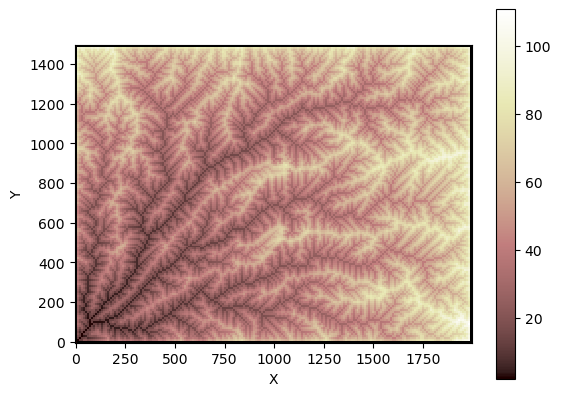

In [65]:
imshow_grid(mg, "topographic__elevation")

#### Space without Rainfall

In [66]:
ha = Space(
    mg,
    K_sed=0.001,
    K_br=0.000001,
    F_f=0.5,
    phi=0.1,
    H_star=1.0,
    v_s=0.001,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

Make a list of all the nodes IDs of our main channel using ChannelProfiler

In [67]:
lp = list(profiler.data_structure[0].values())[0]['ids'] 

In [68]:
print(lp)

[    0   201   402   603   803  1004  1205  1406  1607  1807  2007  2207
  2408  2609  2810  3011  3212  3413  3613  3814  4015  4216  4217  4418
  4619  4820  4821  5022  5223  5424  5625  5826  6026  6226  6427  6628
  6829  7030  7230  7431  7631  7831  8031  8231  8431  8632  8832  9033
  9234  9435  9635  9835 10036 10236 10437 10637 10837 11038 11239 11240
 11441 11442 11643 11844 12045 12246 12447 12648 12849 13049 13250 13451
 13652 13853 14054 14255 14455 14655 14855 15056 15257 15458 15659 15860
 16061 16262 16462 16662 16863 17064 17265 17466 17667 17668 17669 17870
 18071 18072 18273 18474 18675 18676 18677 18878 18879 18880 18881 18882
 19083 19284 19285 19286 19287 19488 19689 19890 20091 20092 20293 20494
 20495 20496 20697 20898 21099 21300 21501 21702 21903 22104 22304 22505
 22706 22707 22708 22909 23110 23111 23312 23513 23714 23715 23516 23517
 23318 23519 23720 23721 23722 23723 23724 23725 23926 23927 23928 23929
 23930 24131 24132 24333 24534 24335 24336 24337 24

Find out how many nodes our channel has, so we can save information later about them in the for loop

In [69]:
print(len(lp))

234


Make empty arrays of size where the number of rows is the number of timesteps, and the number of columns is the number of nodes in our main channel.

In [77]:
lpn = np.zeros([36, 234])

In [78]:
lpd = np.zeros([36, 234])

In [79]:
lpe = np.zeros([36, 234])

In [73]:
lpn

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(336, 234))

model run completed for dt 0
model run completed for dt 1
model run completed for dt 2
model run completed for dt 3
model run completed for dt 4
model run completed for dt 5
model run completed for dt 6
model run completed for dt 7
model run completed for dt 8
model run completed for dt 9
model run completed for dt 10
model run completed for dt 11
model run completed for dt 12
model run completed for dt 13
model run completed for dt 14
model run completed for dt 15
model run completed for dt 16
model run completed for dt 17
model run completed for dt 18
model run completed for dt 19
model run completed for dt 20
model run completed for dt 21
model run completed for dt 22
model run completed for dt 23
model run completed for dt 24
model run completed for dt 25
model run completed for dt 26
model run completed for dt 27
model run completed for dt 28
model run completed for dt 29
model run completed for dt 30
model run completed for dt 31
model run completed for dt 32
model run completed 

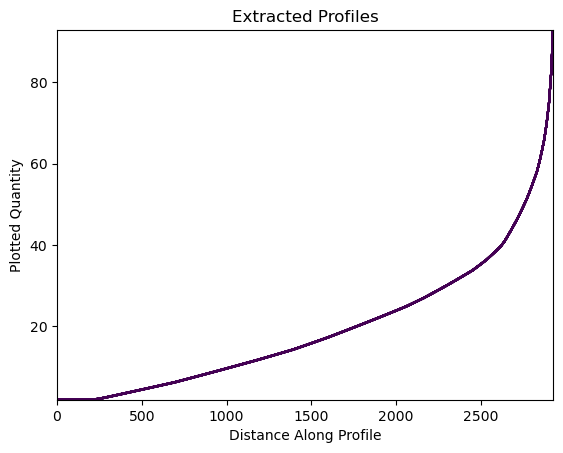

In [80]:
### This one takes 10 mins to run

fsc_dt = 100.0
space_dt = 1.0
df = DepressionFinderAndRouter(mg) 
for i in range(36):  # Space component loop
    fr.run_one_step()
    df.map_depressions()
    ha.run_one_step(dt=space_dt)
    profiler.plot_profiles()
    lpn[i,:] = list(profiler.data_structure[0].values())[0]['ids']
    lpd[i,:] = list(profiler.data_structure[0].values())[0]['distances']
    lpe[i,:] = mg.at_node["topographic__elevation"][lpn[i].astype(int)]
    # mg.at_node["bedrock__elevation"][0] -= 2e-6 * space_dt
    print(f"model run completed for dt {i}")

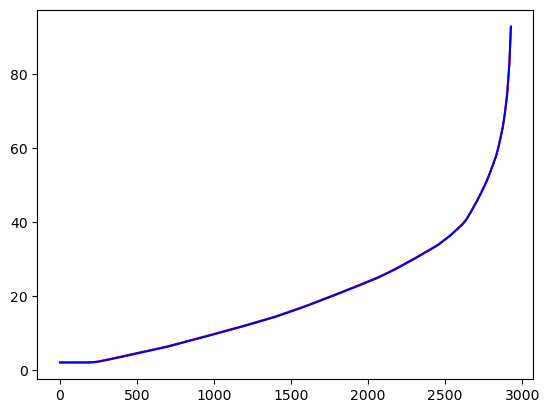

In [84]:
plt.plot(lpd[1], lpe[1], label='T1', color = 'red')
#plt.plot(lpd[50], lpe[1], label='T1', color = 'orange')
#plt.plot(lpd[500], lpe[1], label='T1', color = 'green')
plt.plot(lpd[35], lpe[35], label='T2', color = 'blue')

In [153]:
np.around(mg.at_node["soil__depth"], decimals=3)

array([0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5], shape=(30000,))

In [154]:
np.around(mg.at_node["topographic__elevation"], decimals=3)

array([0.501, 0.501, 0.501, ..., 0.501, 0.501, 0.501], shape=(30000,))

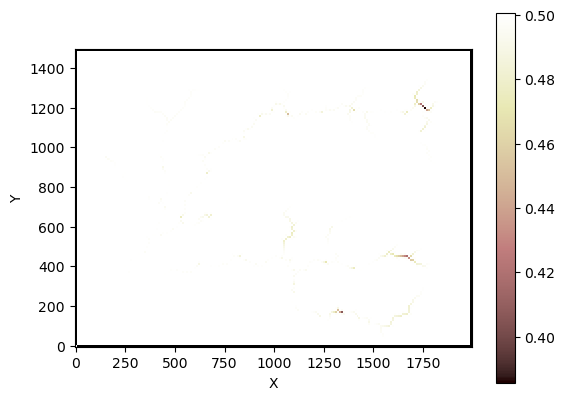

In [158]:
# imshow_grid(mg, "topographic__elevation")
imshow_grid(mg, "topographic__elevation")

In [156]:
mg.at_node.keys()

['topographic__elevation',
 'water__unit_flux_in',
 'drainage_area',
 'flow__data_structure_delta',
 'flow__upstream_node_order',
 'surface_water__discharge',
 'flow__sink_flag',
 'flow__link_to_receiver_node',
 'flow__receiver_node',
 'topographic__steepest_slope',
 'soil__depth',
 'sediment__influx',
 'sediment__outflux',
 'sediment__flux',
 'bedrock__elevation',
 'depression__depth',
 'depression__outlet_node',
 'is_pit',
 'flood_status_code']

## Space with Single Rainfall as Runoff

In [17]:
_ = mg.add_zeros("soil__depth", at="node", dtype=float)
mg.at_node["soil__depth"] += 2.0
mg.at_node["topographic__elevation"] += mg.at_node["soil__depth"]

FieldError: Unable to add the field, 'soil__depth', to the group, 'node', because a field with that name already exists in that group. Use `clobber=True` to replace the existing field. For example, grid.add_field('soil__depth', at='node', clobber=True)

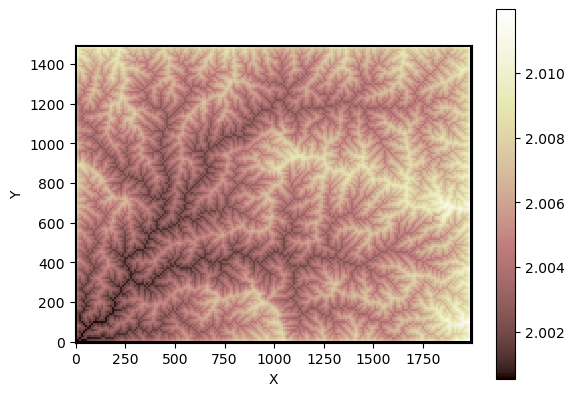

In [18]:
imshow_grid(mg, "topographic__elevation")

#### Space

In [21]:
ha = Space(
    mg,
    K_sed=0.0001,
    K_br=0.000000001,
    F_f=0.5,
    phi=0.1,
    H_star=1.0,
    v_s=0.001,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

In [22]:
### This one takes 10 mins to run

fr = FlowAccumulator(mg, flow_director="D8", runoff_rate = 23.0)
df = DepressionFinderAndRouter(mg)

fsc_dt = 100.0
space_dt = 1.0
df = DepressionFinderAndRouter(mg) 
for _ in range(36):  # Space component loop
    fr.run_one_step()
    df.map_depressions()
    ha.run_one_step(dt=space_dt)
    # mg.at_node["bedrock__elevation"][0] -= 2e-6 * space_dt
    print(f"model run completed for dt {_}")

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!
model run completed for dt 0
model run completed for dt 1
model run completed for dt 2
model run completed for dt 3
model run completed for dt 4
model run completed for dt 5
model run completed for dt 6
model run completed for dt 7
model run completed for dt 8
model run completed for dt 9
model run completed for dt 10
model run completed for dt 11
model run completed for dt 12
model run completed for dt 13
model run completed for dt 14
model run completed for dt 15
model run completed for dt 16
model run completed for dt 17
model run completed for dt 18
model run completed for dt 19
model run completed for dt 20
model run completed for dt 21
model run completed for dt 22
model run completed for dt 23
model run completed for dt 24
model run completed for dt 25
model run completed for dt 26
model run completed

In [23]:
np.around(mg.at_node["soil__depth"], decimals=3)

array([2., 2., 2., ..., 2., 2., 2.], shape=(30000,))

In [24]:
np.around(mg.at_node["topographic__elevation"], decimals=3)

array([2.001, 2.001, 2.001, ..., 2.001, 2.001, 2.001], shape=(30000,))

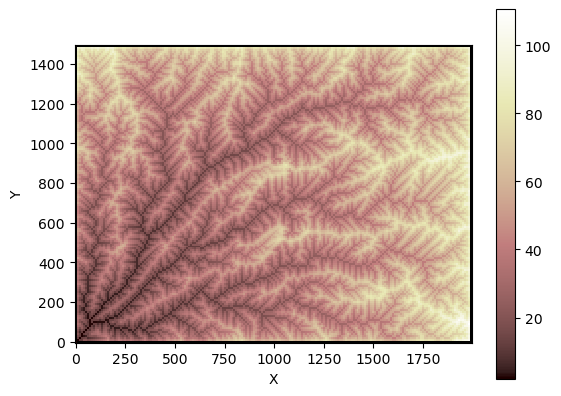

In [25]:
# imshow_grid(mg, "topographic__elevation")
imshow_grid(mg, "topographic__elevation")

## Space with Variable Rainfall as Runoff

In [37]:
_ = mg.add_zeros("soil__depth", at="node", dtype=float)
mg.at_node["soil__depth"] += 2.0
mg.at_node["topographic__elevation"] += mg.at_node["soil__depth"]

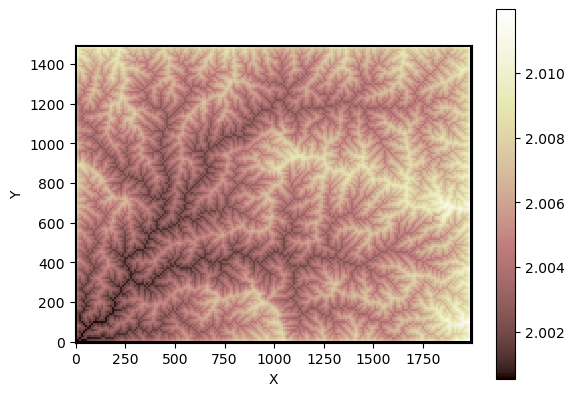

In [38]:
imshow_grid(mg, "topographic__elevation")

#### Space

In [49]:
ha = Space(
    mg,
    K_sed=0.0001,
    K_br=0.000000001,
    F_f=0.5,
    phi=0.1,
    H_star=1.0,
    v_s=0.001,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

In [79]:
runoff_array = np.random.rand(36)
len(runoff_array)
np.random.uniform(0, 5, 36).mean()
np.clip(np.random.normal(2, 0.5, 36), 0, None).mean()

np.float64(2.0586816040759803)

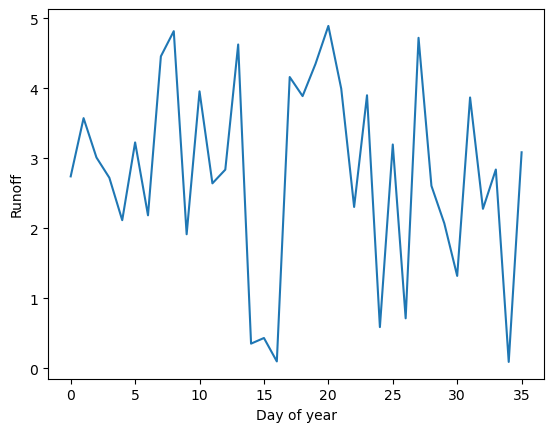

In [81]:
## Runoff timeseries
# runoff_array = np.narry(365 values)
# plot runoff_array

np.random.seed(0)
runoff_array = np.random.uniform(0, 5, 36)



import matplotlib.pyplot as plt
plt.plot(runoff_array)
plt.xlabel("Day of year")
plt.ylabel("Runoff")
plt.show()

In [82]:
### This one takes 10 mins to run

# fr = FlowAccumulator(mg, flow_director="D8", runoff_rate = 23.0)
df = DepressionFinderAndRouter(mg)

fsc_dt = 100.0
space_dt = 1.0
df = DepressionFinderAndRouter(mg) 
for _ in range(36):  # Space component loop
    fr = FlowAccumulator(mg, flow_director="D8", runoff_rate = runoff_array[_])
    fr.run_one_step()
    df.map_depressions()
    ha.run_one_step(dt=space_dt)
    # mg.at_node["bedrock__elevation"][0] -= 2e-6 * space_dt
    print(f"model run completed for dt {_}")

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!
model run completed for dt 0
FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!
model run completed for dt 1
FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!
model run completed for dt 2
FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!
model run completed for dt 3
FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE S

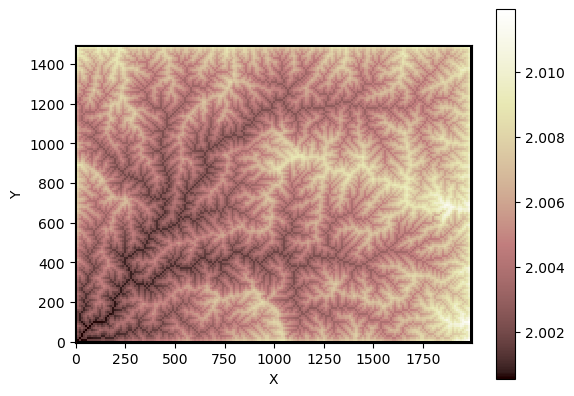

In [85]:
# imshow_grid(mg, "topographic__elevation")
imshow_grid(mg, "topographic__elevation")

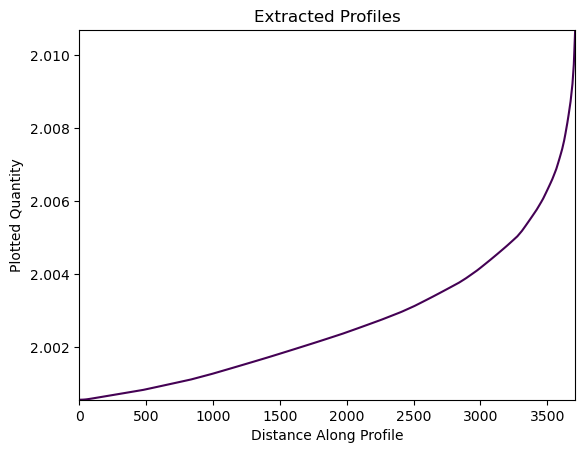

In [87]:
# Instantiate the ChannelProfiler component.
# The drainage area map can be helpful for deciding the minimum channel threshold.
prf = ChannelProfiler(mg, number_of_watersheds=1, minimum_channel_threshold=1e2)

# Run the component and plot the profiles
prf.run_one_step()
prf.plot_profiles()

In [126]:
# Plot the channels on map
# prf.plot_profiles_in_map_view()
# prf.nodes

In [89]:
mg.at_node.keys()

['topographic__elevation',
 'drainage_area',
 'flow__data_structure_delta',
 'flow__upstream_node_order',
 'surface_water__discharge',
 'flow__link_to_receiver_node',
 'flow__receiver_node',
 'topographic__steepest_slope',
 'soil__depth',
 'sediment__influx',
 'sediment__outflux',
 'sediment__flux',
 'bedrock__elevation',
 'depression__depth',
 'depression__outlet_node',
 'is_pit',
 'flood_status_code',
 'water__unit_flux_in',
 'flow__sink_flag']

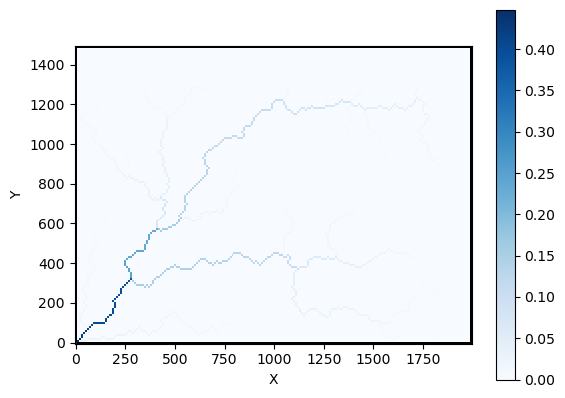

In [104]:
# imshow_grid(mg, "topographic__elevation")
imshow_grid(mg, "sediment__influx", cmap="Blues")

## Field Extraction at Specific Node

In [20]:
mg.at_node["topographic__elevation"][0],
mg.at_node["sediment__influx"][0],
mg.at_node["sediment__outflux"][0], 
mg.at_node["bedrock__elevation"][0],
mg.at_node["surface_water__discharge"][0]

topoelevation.append(np.round((mg.at_node["topographic__elevation"][0]), decimals=5))

#### Space Run

In [12]:
_ = mg.add_zeros("soil__depth", at="node", dtype=float)
mg.at_node["soil__depth"] += 2.0
mg.at_node["topographic__elevation"] += mg.at_node["soil__depth"]


In [13]:
elevation_T1 = mg.at_node["topographic__elevation"]
max(elevation_T1)

array([2.00054881, 2.00071519, 2.00060276, ..., 2.0008529 , 2.00073423,
       2.000639  ], shape=(30000,))

In [31]:
max(elevation_T1), min(elevation_T1)

(np.float64(108.19079964822241), np.float64(-4.5176653592020015))

In [14]:
ha = Space(
    mg,
    K_sed=0.01,
    K_br=0.001,
    F_f=1,
    phi=0.1,
    H_star=1.0,
    v_s=1,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

In [15]:
runoff_array = np.random.rand(30)
len(runoff_array)

30

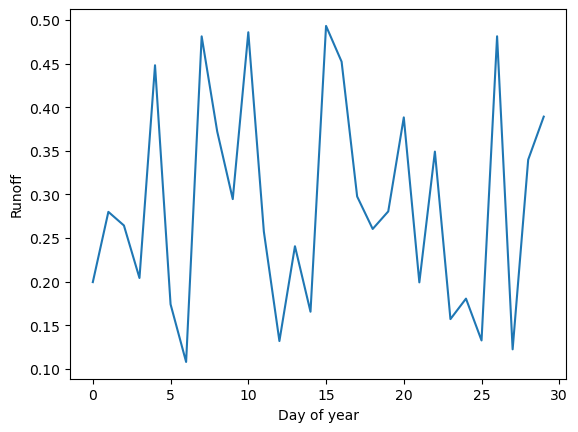

In [18]:
np.random.seed(33)
runoff_array = np.random.uniform(0.1, 0.5, 30)

plt.plot(runoff_array)
plt.xlabel("Day of year")
plt.ylabel("Runoff")
plt.show()

In [19]:
topoelevation = []
sed_in = []
sed_out = []
sed_flux = []
discharge = []
bedrock_elvtn = []

# mg.at_node["topographic__elevation"][0],
# mg.at_node["sediment__influx"][0],
# mg.at_node["sediment__outflux"][0], 
# mg.at_node["bedrock__elevation"][0],
# mg.at_node["surface_water__discharge"][0]

In [20]:
### This one takes 10 mins to run

space_dt = 10.0
df = DepressionFinderAndRouter(mg) 
for _ in trange(30):  # Space component loop
    fr = FlowAccumulator(mg, flow_director="D8", runoff_rate = runoff_array[_])
    fr.run_one_step()
    df.map_depressions()
    ha.run_one_step(dt=space_dt)
    topoelevation.append(np.round((mg.at_node["topographic__elevation"][0]), decimals=5))
    sed_in.append(np.round((mg.at_node["sediment__influx"][0]), decimals=5))
    sed_out.append(np.round((mg.at_node["sediment__outflux"][0]), decimals=5))
    sed_flux.append(np.round((mg.at_node["sediment__flux"][0]), decimals=5))
    discharge.append(np.round((mg.at_node["surface_water__discharge"][0]), decimals=5))
    bedrock_elvtn.append(np.round((mg.at_node["bedrock__elevation"][0]), decimals=5))
    # print(f"model run completed for dt {_}")

  0%|          | 0/30 [00:00<?, ?it/s]

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!


  3%|▎         | 1/30 [00:03<01:28,  3.04s/it]

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!


  7%|▋         | 2/30 [00:05<01:17,  2.78s/it]

...

 93%|█████████▎| 28/30 [01:15<00:05,  2.71s/it]

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!


 97%|█████████▋| 29/30 [01:17<00:02,  2.63s/it]

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!


100%|██████████| 30/30 [01:20<00:00,  2.68s/it]


In [21]:
min(mg.at_node["topographic__elevation"])

np.float64(-4.5176653592020015)

In [25]:
# imshow_grid(mg, "topographic__elevation", cmap="Spectral")

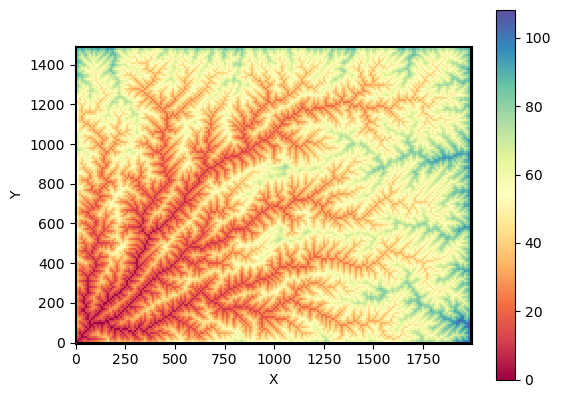

In [26]:
imshow_grid(mg, "topographic__elevation", cmap="Spectral", vmin=0)

In [28]:
elevation_TX = mg.at_node["topographic__elevation"]
topoelvtn_diff = elevation_TX - elevation_T1
max(topoelvtn_diff), min(topoelvtn_diff) 

(np.float64(0.0), np.float64(0.0))

In [29]:
elevation_TX

array([2.00054881, 2.00071519, 2.00060276, ..., 2.0008529 , 2.00073423,
       2.000639  ], shape=(30000,))

In [30]:
elevation_T1

array([2.00054881, 2.00071519, 2.00060276, ..., 2.0008529 , 2.00073423,
       2.000639  ], shape=(30000,))

In [ ]:
plt.title("Scatter Plot with Seaborn")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.grid(True)
plt.show()

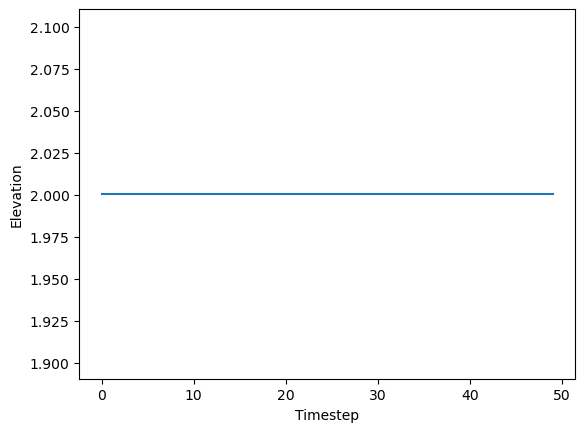

In [19]:
timesteps = np.arange(0, 50)

plt.plot(timesteps, topoelevation)
plt.xlabel("Timestep")
plt.ylabel("Elevation")
plt.show()

## Viz Ideas

- Rivers Water Level with Soil Level
- 1961 to 2014 ------ Resulted more than 20m Sediment Accumulation [Resulted in capactiy loss of the dam]
- 